<a href="https://colab.research.google.com/github/ponzek/MNIST_ClassicalMLvsQML/blob/main/300_SVM_QSVM_PL_Cirq.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#SVM

🚀 SVM BASELINE: 300 samples, 7 runs

📦 Loading MNIST (0 vs 1)...
Total 0/1 samples: 14780

🔷 Run 1/7 (seed=42)
   Train: 300 samples, Test: 150 samples
   ✅ Acc=100.0%, F1=1.000, Time=0.02s

🔷 Run 2/7 (seed=43)
   Train: 300 samples, Test: 150 samples
   ✅ Acc=100.0%, F1=1.000, Time=0.02s

🔷 Run 3/7 (seed=44)
   Train: 300 samples, Test: 150 samples
   ✅ Acc=99.3%, F1=0.993, Time=0.02s

🔷 Run 4/7 (seed=45)
   Train: 300 samples, Test: 150 samples
   ✅ Acc=98.7%, F1=0.986, Time=0.02s

🔷 Run 5/7 (seed=46)
   Train: 300 samples, Test: 150 samples
   ✅ Acc=99.3%, F1=0.994, Time=0.02s

🔷 Run 6/7 (seed=47)
   Train: 300 samples, Test: 150 samples
   ✅ Acc=99.3%, F1=0.993, Time=0.01s

🔷 Run 7/7 (seed=48)
   Train: 300 samples, Test: 150 samples
   ✅ Acc=100.0%, F1=1.000, Time=0.02s

📊 SVM RESULTS: 7 runs with 300 samples

Metric          Mean       Std        95% CI              
-------------------------------------------------------
Accuracy        99.5%    ±0.5%    [99.1%, 100.0%]
Precisio

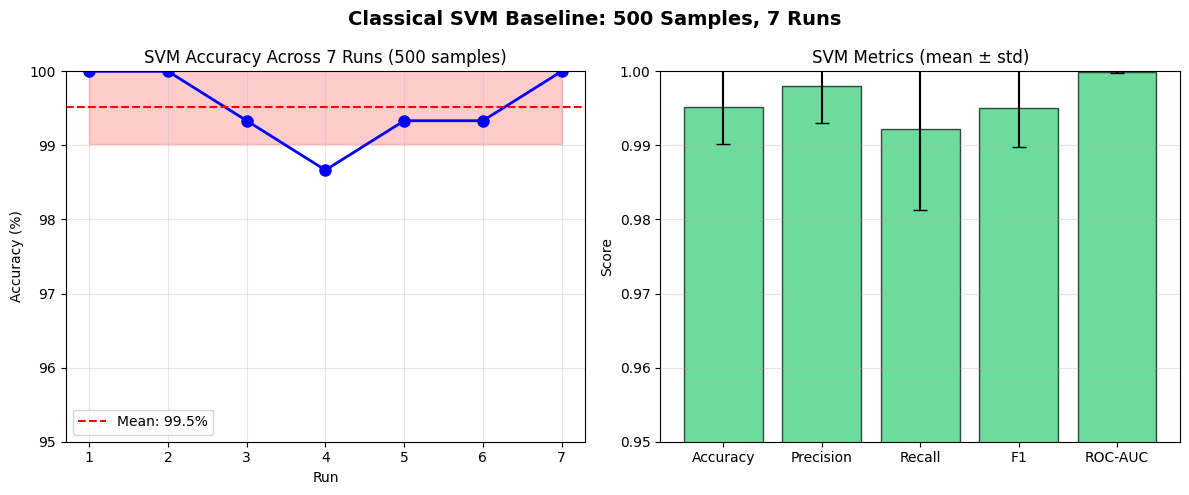


✅ DONE! SVM baseline complete!


In [ ]:
# ============================================
# SVM BASELINE - 300 samples, 7 runs
# Fast, simple, gives you mean ± std for paper
# ============================================

import numpy as np
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
import time
import pandas as pd
from datetime import datetime

print("="*60)
print("🚀 SVM BASELINE: 300 samples, 7 runs")
print("="*60)

# Load MNIST
print("\n📦 Loading MNIST (0 vs 1)...")
mnist = fetch_openml('mnist_784', version=1, as_frame=False)
X, y = mnist.data, mnist.target.astype(int)

# Filter 0 and 1
mask = (y == 0) | (y == 1)
X, y = X[mask], y[mask]
print(f"Total 0/1 samples: {len(y)}")

# Scale once
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Store results
svm_results = []

for run in range(7):
    print(f"\n🔷 Run {run+1}/7 (seed={42+run})")

    # Different split each run
    X_train, X_test, y_train, y_test = train_test_split(
        X_scaled, y, test_size=0.3, random_state=42+run, stratify=y
    )

    # PCA to 2D
    pca = PCA(n_components=2)
    X_train_pca = pca.fit_transform(X_train)
    X_test_pca = pca.transform(X_test)

    # TAKE EXACTLY 500 SAMPLES
    X_train_300 = X_train_pca[:300]
    y_train_300 = y_train[:300]
    X_test_150 = X_test_pca[:150]  # Proportional test set
    y_test_150 = y_test[:150]

    print(f"   Train: {len(X_train_300)} samples, Test: {len(X_test_150)} samples")

    # Train SVM
    start = time.time()
    svm = SVC(kernel='rbf', C=1.0, probability=True)
    svm.fit(X_train_300, y_train_300)
    y_pred = svm.predict(X_test_150)
    y_prob = svm.predict_proba(X_test_150)[:, 1]

    # Calculate ALL metrics
    from sklearn.metrics import roc_auc_score
    svm_results.append({
        'run': run+1,
        'accuracy': accuracy_score(y_test_150, y_pred) * 100,
        'precision': precision_score(y_test_150, y_pred, average='binary'),
        'recall': recall_score(y_test_150, y_pred, average='binary'),
        'f1': f1_score(y_test_150, y_pred, average='binary'),
        'roc_auc': roc_auc_score(y_test_150, y_prob),
        'time': time.time() - start
    })

    print(f"   ✅ Acc={svm_results[-1]['accuracy']:.1f}%, F1={svm_results[-1]['f1']:.3f}, Time={svm_results[-1]['time']:.2f}s")

# ============================================
# RESULTS WITH STATISTICS
# ============================================
print("\n" + "="*60)
print("📊 SVM RESULTS: 7 runs with 300 samples")
print("="*60)

df = pd.DataFrame(svm_results)

print(f"\n{'Metric':<15} {'Mean':<10} {'Std':<10} {'95% CI':<20}")
print("-" * 55)

from scipy import stats

for metric in ['accuracy', 'precision', 'recall', 'f1', 'roc_auc', 'time']:
    values = df[metric].values
    mean_val = np.mean(values)
    std_val = np.std(values)
    ci = stats.t.interval(0.95, len(values)-1, loc=mean_val, scale=stats.sem(values))

    if metric == 'accuracy':
        print(f"{metric.capitalize():<15} {mean_val:.1f}%    ±{std_val:.1f}%    [{ci[0]:.1f}%, {ci[1]:.1f}%]")
    elif metric == 'time':
        print(f"{metric.capitalize():<15} {mean_val:.2f}s   ±{std_val:.2f}s   [{ci[0]:.2f}s, {ci[1]:.2f}s]")
    else:
        print(f"{metric.capitalize():<15} {mean_val:.3f}    ±{std_val:.3f}    [{ci[0]:.3f}, {ci[1]:.3f}]")

# ============================================
# SAVE RESULTS
# ============================================
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
filename = f"svm_500samples_7runs_{timestamp}.csv"
df.to_csv(filename, index=False)
print(f"\n💾 Saved to {filename}")

# ============================================
# QUICK PLOT
# ============================================
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Accuracy across runs
ax1.plot(range(1, 8), df['accuracy'], 'bo-', linewidth=2, markersize=8)
ax1.axhline(y=df['accuracy'].mean(), color='r', linestyle='--', label=f"Mean: {df['accuracy'].mean():.1f}%")
ax1.fill_between(range(1, 8),
                 df['accuracy'].mean() - df['accuracy'].std(),
                 df['accuracy'].mean() + df['accuracy'].std(),
                 alpha=0.2, color='r')
ax1.set_xlabel('Run')
ax1.set_ylabel('Accuracy (%)')
ax1.set_title('SVM Accuracy Across 7 Runs (500 samples)')
ax1.set_ylim(95, 100)
ax1.legend()
ax1.grid(True, alpha=0.3)

# Metrics bar chart
metrics = ['Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC']
values = [df['accuracy'].mean()/100, df['precision'].mean(), df['recall'].mean(), df['f1'].mean(), df['roc_auc'].mean()]
errors = [df['accuracy'].std()/100, df['precision'].std(), df['recall'].std(), df['f1'].std(), df['roc_auc'].std()]

ax2.bar(metrics, values, yerr=errors, capsize=5, color='#2ecc71', edgecolor='black', alpha=0.7)
ax2.set_ylabel('Score')
ax2.set_title('SVM Metrics (mean ± std)')
ax2.set_ylim(0.95, 1.0)
ax2.grid(True, alpha=0.3, axis='y')

plt.suptitle('Classical SVM Baseline: 500 Samples, 7 Runs', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('svm_500samples_results.png', dpi=150)
plt.show()

print("\n✅ DONE! SVM baseline complete!")

#QSVM

##Pennylane

###Configuration A: WITHOUT ZZFeatureMap (Basic Circuit)

Circuit: H + RY encoding only (no entanglement)

This matches what was already ran for SVM baseline

In [ ]:
# ============================================
# CELL 1: PENNYLANE BASIC CIRCUIT (NO ZZ)
# H + RY encoding only - 300 samples, 7 runs
# ============================================

!pip install pennylane scikit-learn pandas --quiet

import numpy as np
import pennylane as qml
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_auc_score
import time
import pandas as pd
from scipy import stats
from datetime import datetime

print("="*60)
print("🔹 CELL 1: PENNYLANE BASIC (NO ZZ) - 300 samples, 7 runs")
print("="*60)

# Load MNIST
mnist = fetch_openml('mnist_784', version=1, as_frame=False)
X, y = mnist.data, mnist.target.astype(int)
mask = (y == 0) | (y == 1)
X, y = X[mask], y[mask]

# Scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Store results
results_basic = []

for run in range(7):
    print(f"\n🔷 Run {run+1}/7 (seed={42+run})")

    # Split data
    X_train, X_test, y_train, y_test = train_test_split(
        X_scaled, y, test_size=0.3, random_state=42+run, stratify=y
    )

    # PCA to 2D
    pca = PCA(n_components=2)
    X_train_pca = pca.fit_transform(X_train)
    X_test_pca = pca.transform(X_test)

    # TAKE EXACTLY 300 SAMPLES
    X_train_300 = X_train_pca[:300]
    y_train_300 = y_train[:300]
    X_test_150 = X_test_pca[:150]
    y_test_150 = y_test[:150]

    # Scale for quantum circuits
    X_train_scaled = X_train_300 * np.pi
    X_test_scaled = X_test_150 * np.pi

    print(f"   Train: {len(X_train_300)} samples, Test: {len(X_test_150)} samples")

    # BASIC CIRCUIT DEVICE
    dev_basic = qml.device("default.qubit", wires=2)

    @qml.qnode(dev_basic)
    def get_state_basic(x):
        """Basic H + RY encoding - NO ZZ"""
        qml.Hadamard(wires=0)
        qml.Hadamard(wires=1)
        qml.RY(x[0], wires=0)
        qml.RY(x[1], wires=1)
        return qml.state()

    start_basic = time.time()

    # Pre-compute states
    states_train_basic = [get_state_basic(x) for x in X_train_scaled]
    states_test_basic = [get_state_basic(x) for x in X_test_scaled]

    # Compute kernel matrix
    print("   Computing kernel matrices...")
    K_train_basic = np.zeros((300, 300))
    for i in range(300):
        for j in range(i, 300):
            val = qml.math.fidelity_statevector(states_train_basic[i], states_train_basic[j])
            K_train_basic[i,j] = val
            K_train_basic[j,i] = val

    K_test_basic = np.zeros((150, 300))
    for i in range(150):
        for j in range(300):
            K_test_basic[i,j] = qml.math.fidelity_statevector(states_test_basic[i], states_train_basic[j])

    # Train QSVM
    qsvm_basic = SVC(kernel='precomputed', probability=True)
    qsvm_basic.fit(K_train_basic, y_train_300)
    y_pred_basic = qsvm_basic.predict(K_test_basic)
    y_score_basic = qsvm_basic.decision_function(K_test_basic)
    y_score_norm_basic = (y_score_basic - y_score_basic.min()) / (y_score_basic.max() - y_score_basic.min() + 1e-10)

    time_basic = time.time() - start_basic

    # Store results
    results_basic.append({
        'run': run+1,
        'circuit': 'Basic H+RY (NO ZZ)',
        'accuracy': accuracy_score(y_test_150, y_pred_basic) * 100,
        'precision': precision_score(y_test_150, y_pred_basic, average='binary'),
        'recall': recall_score(y_test_150, y_pred_basic, average='binary'),
        'f1': f1_score(y_test_150, y_pred_basic, average='binary'),
        'roc_auc': roc_auc_score(y_test_150, y_score_norm_basic),
        'time': time_basic
    })

    print(f"   ✅ Acc={results_basic[-1]['accuracy']:.1f}%, F1={results_basic[-1]['f1']:.3f}, Time={time_basic:.1f}s")

# ============================================
# RESULTS
# ============================================
print("\n" + "="*60)
print("📊 BASIC CIRCUIT (NO ZZ) - RESULTS")
print("="*60)

df_basic = pd.DataFrame(results_basic)

print(f"\n{'Metric':<15} {'Mean':<10} {'Std':<10} {'95% CI':<20}")
print("-" * 55)

for metric in ['accuracy', 'precision', 'recall', 'f1', 'roc_auc', 'time']:
    values = df_basic[metric].values
    mean_val = np.mean(values)
    std_val = np.std(values)
    ci = stats.t.interval(0.95, len(values)-1, loc=mean_val, scale=stats.sem(values))

    if metric == 'accuracy':
        print(f"{metric.capitalize():<15} {mean_val:.1f}%    ±{std_val:.1f}%    [{ci[0]:.1f}%, {ci[1]:.1f}%]")
    elif metric == 'time':
        print(f"{metric.capitalize():<15} {mean_val:.1f}s   ±{std_val:.1f}s   [{ci[0]:.1f}s, {ci[1]:.1f}s]")
    else:
        print(f"{metric.capitalize():<15} {mean_val:.3f}    ±{std_val:.3f}    [{ci[0]:.3f}, {ci[1]:.3f}]")

# Save
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
filename = f"pennylane_basic_NOzz_300_{timestamp}.csv"
df_basic.to_csv(filename, index=False)
print(f"\n💾 Saved to {filename}")
print("\n✅ CELL 1 COMPLETE! Run CELL 2 next.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 61.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 935.6/935.6 kB 57.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.9/167.9 kB 18.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 111.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 108.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 140.4 MB/s eta 0:00:00
🔹 CELL 1: PENNYLANE BASIC (NO ZZ) - 300 samples, 7 runs

🔷 Run 1/7 (seed=42)
   Train: 300 samples, Test: 150 samples
   Computing kernel matrices...
   ✅ Acc=49.3%, F1=0.397, Time=7.3s

🔷 Run 2/7 (seed=43)
   Train: 300 samples, Test: 150 samples
   Computing kernel matrices...
   ✅ Acc=58.7%, F1=0.648, Time=7.2s

🔷 Run 3/7 (seed=44)
   Train: 300 samples, Test: 150 samples
   Computing kernel matrices...
   ✅ Acc=52.0%, F1=0.604, Time=7.2s



###Configuration B: : WITH ZZFeatureMap

Circuit: H + RZ + CZ + RZ (the standard ZZFeatureMap with 2 repetitions)

This matches what you originally used for Qiskit/PennyLane

In [ ]:
# ============================================
# CELL 2: PENNYLANE ZZFEATUREMAP (WITH ZZ)
# H + RZ + CZ + RZ - 300 samples, 7 runs
# ============================================

!pip install pennylane scikit-learn pandas --quiet

import numpy as np
import pennylane as qml
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_auc_score
import time
import pandas as pd
from scipy import stats
from datetime import datetime

print("="*60)
print("🔸 CELL 2: PENNYLANE ZZFEATUREMAP (WITH ZZ) - 300 samples, 7 runs")
print("="*60)

# Load MNIST
mnist = fetch_openml('mnist_784', version=1, as_frame=False)
X, y = mnist.data, mnist.target.astype(int)
mask = (y == 0) | (y == 1)
X, y = X[mask], y[mask]

# Scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Store results
results_zz = []

for run in range(7):
    print(f"\n🔷 Run {run+1}/7 (seed={42+run})")

    # Split data
    X_train, X_test, y_train, y_test = train_test_split(
        X_scaled, y, test_size=0.3, random_state=42+run, stratify=y
    )

    # PCA to 2D
    pca = PCA(n_components=2)
    X_train_pca = pca.fit_transform(X_train)
    X_test_pca = pca.transform(X_test)

    # TAKE EXACTLY 300 SAMPLES
    X_train_300 = X_train_pca[:300]
    y_train_300 = y_train[:300]
    X_test_150 = X_test_pca[:150]
    y_test_150 = y_test[:150]

    # Scale for quantum circuits
    X_train_scaled = X_train_300 * np.pi
    X_test_scaled = X_test_150 * np.pi

    print(f"   Train: {len(X_train_300)} samples, Test: {len(X_test_150)} samples")

    # ZZFEATUREMAP DEVICE
    dev_zz = qml.device("default.qubit", wires=2)

    @qml.qnode(dev_zz)
    def get_state_zz(x):
        """ZZFeatureMap with 2 repetitions"""
        # Initial Hadamards
        for i in range(2):
            qml.Hadamard(wires=i)

        # 2 repetitions of ZZFeatureMap
        for _ in range(2):
            # RZ rotations
            for i in range(2):
                qml.RZ(x[i], wires=i)
            # CZ entanglement
            qml.CZ(wires=[0, 1])
            # Second RZ layer
            for i in range(2):
                qml.RZ(x[i], wires=i)

        return qml.state()

    start_zz = time.time()

    # Pre-compute states
    print("   Pre-computing quantum states...")
    states_train_zz = [get_state_zz(x) for x in X_train_scaled]
    states_test_zz = [get_state_zz(x) for x in X_test_scaled]

    # Compute kernel matrix
    print("   Computing kernel matrices...")
    K_train_zz = np.zeros((300, 300))
    for i in range(300):
        for j in range(i, 300):
            val = qml.math.fidelity_statevector(states_train_zz[i], states_train_zz[j])
            K_train_zz[i,j] = val
            K_train_zz[j,i] = val

    K_test_zz = np.zeros((150, 300))
    for i in range(150):
        for j in range(300):
            K_test_zz[i,j] = qml.math.fidelity_statevector(states_test_zz[i], states_train_zz[j])

    # Train QSVM
    qsvm_zz = SVC(kernel='precomputed', probability=True)
    qsvm_zz.fit(K_train_zz, y_train_300)
    y_pred_zz = qsvm_zz.predict(K_test_zz)
    y_score_zz = qsvm_zz.decision_function(K_test_zz)
    y_score_norm_zz = (y_score_zz - y_score_zz.min()) / (y_score_zz.max() - y_score_zz.min() + 1e-10)

    time_zz = time.time() - start_zz

    # Store results
    results_zz.append({
        'run': run+1,
        'circuit': 'ZZFeatureMap (WITH ZZ)',
        'accuracy': accuracy_score(y_test_150, y_pred_zz) * 100,
        'precision': precision_score(y_test_150, y_pred_zz, average='binary'),
        'recall': recall_score(y_test_150, y_pred_zz, average='binary'),
        'f1': f1_score(y_test_150, y_pred_zz, average='binary'),
        'roc_auc': roc_auc_score(y_test_150, y_score_norm_zz),
        'time': time_zz
    })

    print(f"   ✅ Acc={results_zz[-1]['accuracy']:.1f}%, F1={results_zz[-1]['f1']:.3f}, Time={time_zz:.1f}s")

# ============================================
# RESULTS
# ============================================
print("\n" + "="*60)
print("📊 ZZFEATUREMAP (WITH ZZ) - RESULTS")
print("="*60)

df_zz = pd.DataFrame(results_zz)

print(f"\n{'Metric':<15} {'Mean':<10} {'Std':<10} {'95% CI':<20}")
print("-" * 55)

for metric in ['accuracy', 'precision', 'recall', 'f1', 'roc_auc', 'time']:
    values = df_zz[metric].values
    mean_val = np.mean(values)
    std_val = np.std(values)
    ci = stats.t.interval(0.95, len(values)-1, loc=mean_val, scale=stats.sem(values))

    if metric == 'accuracy':
        print(f"{metric.capitalize():<15} {mean_val:.1f}%    ±{std_val:.1f}%    [{ci[0]:.1f}%, {ci[1]:.1f}%]")
    elif metric == 'time':
        print(f"{metric.capitalize():<15} {mean_val:.1f}s   ±{std_val:.1f}s   [{ci[0]:.1f}s, {ci[1]:.1f}s]")
    else:
        print(f"{metric.capitalize():<15} {mean_val:.3f}    ±{std_val:.3f}    [{ci[0]:.3f}, {ci[1]:.3f}]")

# Save
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
filename = f"pennylane_zz_WITHzz_300_{timestamp}.csv"
df_zz.to_csv(filename, index=False)
print(f"\n💾 Saved to {filename}")
print("\n✅ CELL 2 COMPLETE!")

🔸 CELL 2: PENNYLANE ZZFEATUREMAP (WITH ZZ) - 300 samples, 7 runs

🔷 Run 1/7 (seed=42)
   Train: 300 samples, Test: 150 samples
   Pre-computing quantum states...
   Computing kernel matrices...
   ✅ Acc=41.3%, F1=0.443, Time=7.8s

🔷 Run 2/7 (seed=43)
   Train: 300 samples, Test: 150 samples
   Pre-computing quantum states...
   Computing kernel matrices...
   ✅ Acc=52.7%, F1=0.590, Time=7.8s

🔷 Run 3/7 (seed=44)
   Train: 300 samples, Test: 150 samples
   Pre-computing quantum states...
   Computing kernel matrices...
   ✅ Acc=45.3%, F1=0.559, Time=7.5s

🔷 Run 4/7 (seed=45)
   Train: 300 samples, Test: 150 samples
   Pre-computing quantum states...
   Computing kernel matrices...
   ✅ Acc=54.7%, F1=0.638, Time=7.7s

🔷 Run 5/7 (seed=46)
   Train: 300 samples, Test: 150 samples
   Pre-computing quantum states...
   Computing kernel matrices...
   ✅ Acc=55.3%, F1=0.712, Time=7.7s

🔷 Run 6/7 (seed=47)
   Train: 300 samples, Test: 150 samples
   Pre-computing quantum states...
   Computing 

###Graphs between Configure A & B

📊 PENNYLANE GRAPHS - Config A vs Config B

📁 Config A (Basic): pennylane_basic_NOzz_300_20260315_115458.csv
📁 Config B (ZZ): pennylane_zz_WITHzz_300_20260315_115607.csv

✅ Loaded 7 runs of Config A, 7 runs of Config B


/tmp/ipykernel_3512/1977109234.py:221: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax7.boxplot(data_to_plot, labels=['Basic', 'ZZ'], patch_artist=True)


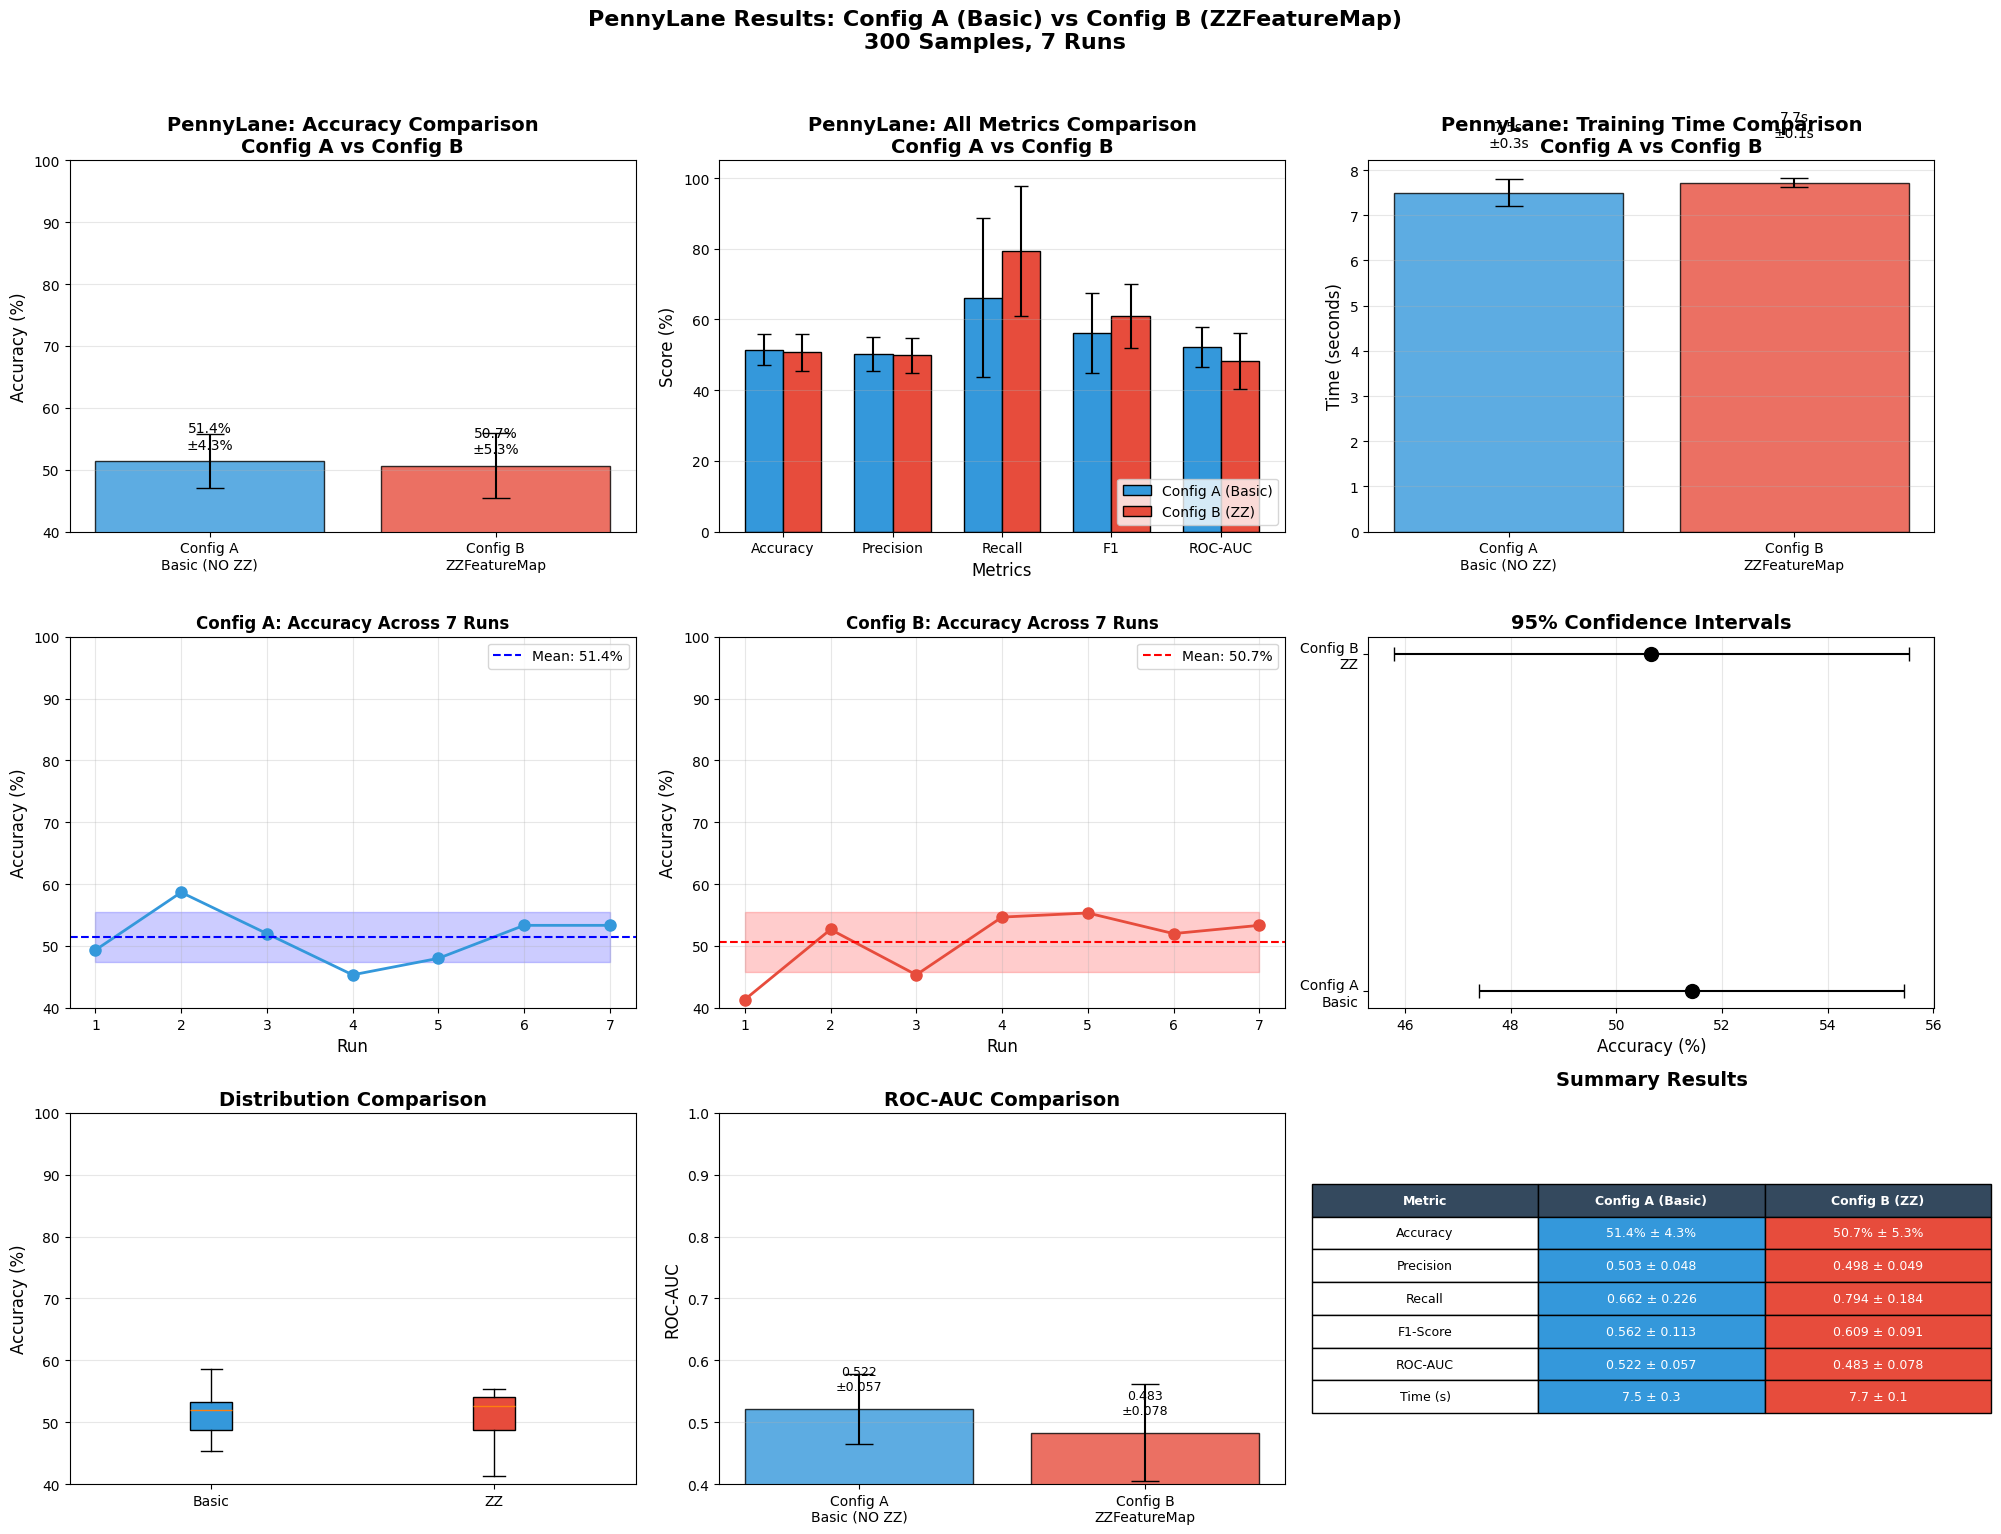


✅ Graphs saved as 'pennylane_configA_vs_configB_results.png'

📊 PENNYLANE SUMMARY STATISTICS - CONFIG A vs CONFIG B

CONFIG A (Basic H+RY, NO ZZ):
   Accuracy:  51.4% ± 4.3%
   Precision: 0.503 ± 0.048
   Recall:    0.662 ± 0.226
   F1-Score:  0.562 ± 0.113
   ROC-AUC:   0.522 ± 0.057
   Time:      7.5s ± 0.3s

CONFIG B (ZZFeatureMap, WITH ZZ):
   Accuracy:  50.7% ± 5.3%
   Precision: 0.498 ± 0.049
   Recall:    0.794 ± 0.184
   F1-Score:  0.609 ± 0.091
   ROC-AUC:   0.483 ± 0.078
   Time:      7.7s ± 0.1s

📊 ACCURACY DIFFERENCE: 0.8%


In [ ]:
# ============================================
# CELL 3: PENNYLANE GRAPHS - Config A vs Config B
# Run this after Cells 1 and 2 complete
# ============================================

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
import glob

print("="*70)
print("📊 PENNYLANE GRAPHS - Config A vs Config B")
print("="*70)

# Find PennyLane result files for both configurations
basic_files = glob.glob('pennylane_basic_NOzz_300_*.csv')
zz_files = glob.glob('pennylane_zz_WITHzz_300_*.csv')

if not basic_files or not zz_files:
    print("❌ Missing results! Make sure both Config A and B files exist.")
    print(f"   Config A files found: {len(basic_files)}")
    print(f"   Config B files found: {len(zz_files)}")
else:
    latest_basic = sorted(basic_files)[-1]
    latest_zz = sorted(zz_files)[-1]

    print(f"\n📁 Config A (Basic): {latest_basic}")
    print(f"📁 Config B (ZZ): {latest_zz}")

    df_basic = pd.read_csv(latest_basic)
    df_zz = pd.read_csv(latest_zz)

    print(f"\n✅ Loaded {len(df_basic)} runs of Config A, {len(df_zz)} runs of Config B")

    # ============================================
    # CREATE FIGURE WITH SUBPLOTS
    # ============================================
    fig = plt.figure(figsize=(20, 15))

    # Colors
    colors = {'A': '#3498db', 'B': '#e74c3c'}

    # ============================================
    # GRAPH 1: Accuracy Comparison (Bar Chart)
    # ============================================
    ax1 = plt.subplot(3, 3, 1)

    configs = ['Config A\nBasic (NO ZZ)', 'Config B\nZZFeatureMap']
    means = [df_basic['accuracy'].mean(), df_zz['accuracy'].mean()]
    stds = [df_basic['accuracy'].std(), df_zz['accuracy'].std()]

    bars = ax1.bar(configs, means, yerr=stds, capsize=10,
                   color=[colors['A'], colors['B']],
                   edgecolor='black', linewidth=1, alpha=0.8)

    ax1.set_ylabel('Accuracy (%)', fontsize=12)
    ax1.set_title('PennyLane: Accuracy Comparison\nConfig A vs Config B',
                  fontsize=14, fontweight='bold')
    ax1.set_ylim(40, 100)
    ax1.grid(True, alpha=0.3, axis='y')

    # Add value labels
    for bar, mean, std in zip(bars, means, stds):
        ax1.text(bar.get_x() + bar.get_width()/2., mean + 2,
                f'{mean:.1f}%\n±{std:.1f}%', ha='center', fontsize=10)

    # ============================================
    # GRAPH 2: All Metrics Comparison
    # ============================================
    ax2 = plt.subplot(3, 3, 2)

    metrics = ['Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC']
    x = np.arange(len(metrics))
    width = 0.35

    # Config A metrics
    A_metrics = [df_basic['accuracy'].mean(),
                 df_basic['precision'].mean() * 100,
                 df_basic['recall'].mean() * 100,
                 df_basic['f1'].mean() * 100,
                 df_basic['roc_auc'].mean() * 100]

    A_stds = [df_basic['accuracy'].std(),
              df_basic['precision'].std() * 100,
              df_basic['recall'].std() * 100,
              df_basic['f1'].std() * 100,
              df_basic['roc_auc'].std() * 100]

    # Config B metrics
    B_metrics = [df_zz['accuracy'].mean(),
                 df_zz['precision'].mean() * 100,
                 df_zz['recall'].mean() * 100,
                 df_zz['f1'].mean() * 100,
                 df_zz['roc_auc'].mean() * 100]

    B_stds = [df_zz['accuracy'].std(),
              df_zz['precision'].std() * 100,
              df_zz['recall'].std() * 100,
              df_zz['f1'].std() * 100,
              df_zz['roc_auc'].std() * 100]

    bars1 = ax2.bar(x - width/2, A_metrics, width, yerr=A_stds,
                    label='Config A (Basic)', color=colors['A'],
                    capsize=5, edgecolor='black')
    bars2 = ax2.bar(x + width/2, B_metrics, width, yerr=B_stds,
                    label='Config B (ZZ)', color=colors['B'],
                    capsize=5, edgecolor='black')

    ax2.set_xlabel('Metrics', fontsize=12)
    ax2.set_ylabel('Score (%)', fontsize=12)
    ax2.set_title('PennyLane: All Metrics Comparison\nConfig A vs Config B',
                  fontsize=14, fontweight='bold')
    ax2.set_xticks(x)
    ax2.set_xticklabels(metrics)
    ax2.set_ylim(0, 105)
    ax2.legend(loc='lower right')
    ax2.grid(True, alpha=0.3, axis='y')

    # ============================================
    # GRAPH 3: Time Comparison
    # ============================================
    ax3 = plt.subplot(3, 3, 3)

    time_means = [df_basic['time'].mean(), df_zz['time'].mean()]
    time_stds = [df_basic['time'].std(), df_zz['time'].std()]

    bars = ax3.bar(configs, time_means, yerr=time_stds, capsize=10,
                   color=[colors['A'], colors['B']],
                   edgecolor='black', linewidth=1, alpha=0.8)

    ax3.set_ylabel('Time (seconds)', fontsize=12)
    ax3.set_title('PennyLane: Training Time Comparison\nConfig A vs Config B',
                  fontsize=14, fontweight='bold')
    ax3.grid(True, alpha=0.3, axis='y')

    for bar, mean, std in zip(bars, time_means, time_stds):
        ax3.text(bar.get_x() + bar.get_width()/2., mean + 1,
                f'{mean:.1f}s\n±{std:.1f}s', ha='center', fontsize=10)

    # ============================================
    # GRAPH 4: Accuracy across runs (Config A)
    # ============================================
    ax4 = plt.subplot(3, 3, 4)

    runs = df_basic['run'].values
    acc_A = df_basic['accuracy'].values

    ax4.plot(runs, acc_A, 'o-', color=colors['A'], linewidth=2, markersize=8)
    ax4.axhline(y=acc_A.mean(), color='blue', linestyle='--',
                label=f"Mean: {acc_A.mean():.1f}%")
    ax4.fill_between(runs,
                     acc_A.mean() - acc_A.std(),
                     acc_A.mean() + acc_A.std(),
                     alpha=0.2, color='blue')

    ax4.set_xlabel('Run', fontsize=12)
    ax4.set_ylabel('Accuracy (%)', fontsize=12)
    ax4.set_title('Config A: Accuracy Across 7 Runs',
                  fontsize=12, fontweight='bold')
    ax4.set_xticks(runs)
    ax4.set_ylim(40, 100)
    ax4.legend()
    ax4.grid(True, alpha=0.3)

    # ============================================
    # GRAPH 5: Accuracy across runs (Config B)
    # ============================================
    ax5 = plt.subplot(3, 3, 5)

    acc_B = df_zz['accuracy'].values

    ax5.plot(runs, acc_B, 'o-', color=colors['B'], linewidth=2, markersize=8)
    ax5.axhline(y=acc_B.mean(), color='red', linestyle='--',
                label=f"Mean: {acc_B.mean():.1f}%")
    ax5.fill_between(runs,
                     acc_B.mean() - acc_B.std(),
                     acc_B.mean() + acc_B.std(),
                     alpha=0.2, color='red')

    ax5.set_xlabel('Run', fontsize=12)
    ax5.set_ylabel('Accuracy (%)', fontsize=12)
    ax5.set_title('Config B: Accuracy Across 7 Runs',
                  fontsize=12, fontweight='bold')
    ax5.set_xticks(runs)
    ax5.set_ylim(40, 100)
    ax5.legend()
    ax5.grid(True, alpha=0.3)

    # ============================================
    # GRAPH 6: 95% Confidence Intervals
    # ============================================
    ax6 = plt.subplot(3, 3, 6)

    ci_A = stats.t.interval(0.95, len(acc_A)-1,
                           loc=acc_A.mean(), scale=stats.sem(acc_A))
    ci_B = stats.t.interval(0.95, len(acc_B)-1,
                           loc=acc_B.mean(), scale=stats.sem(acc_B))

    y_pos = [0, 1]
    means_ci = [acc_A.mean(), acc_B.mean()]
    ci_low = [means_ci[0] - ci_A[0], means_ci[1] - ci_B[0]]
    ci_high = [ci_A[1] - means_ci[0], ci_B[1] - means_ci[1]]

    ax6.errorbar(means_ci, y_pos, xerr=[ci_low, ci_high],
                 fmt='o', color='black', capsize=5, markersize=10)

    ax6.set_yticks(y_pos)
    ax6.set_yticklabels(['Config A\nBasic', 'Config B\nZZ'])
    ax6.set_xlabel('Accuracy (%)', fontsize=12)
    ax6.set_title('95% Confidence Intervals',
                  fontsize=14, fontweight='bold')
    ax6.grid(True, alpha=0.3, axis='x')

    # ============================================
    # GRAPH 7: Box Plot Comparison
    # ============================================
    ax7 = plt.subplot(3, 3, 7)

    data_to_plot = [df_basic['accuracy'], df_zz['accuracy']]
    bp = ax7.boxplot(data_to_plot, labels=['Basic', 'ZZ'], patch_artist=True)

    bp['boxes'][0].set_facecolor(colors['A'])
    bp['boxes'][1].set_facecolor(colors['B'])

    ax7.set_ylabel('Accuracy (%)', fontsize=12)
    ax7.set_title('Distribution Comparison',
                  fontsize=14, fontweight='bold')
    ax7.set_ylim(40, 100)
    ax7.grid(True, alpha=0.3, axis='y')

    # ============================================
    # GRAPH 8: ROC-AUC Comparison
    # ============================================
    ax8 = plt.subplot(3, 3, 8)

    roc_means = [df_basic['roc_auc'].mean(), df_zz['roc_auc'].mean()]
    roc_stds = [df_basic['roc_auc'].std(), df_zz['roc_auc'].std()]

    bars = ax8.bar(configs, roc_means, yerr=roc_stds, capsize=10,
                   color=[colors['A'], colors['B']],
                   edgecolor='black', linewidth=1, alpha=0.8)

    ax8.set_ylabel('ROC-AUC', fontsize=12)
    ax8.set_title('ROC-AUC Comparison',
                  fontsize=14, fontweight='bold')
    ax8.set_ylim(0.4, 1.0)
    ax8.grid(True, alpha=0.3, axis='y')

    for bar, mean, std in zip(bars, roc_means, roc_stds):
        ax8.text(bar.get_x() + bar.get_width()/2., mean + 0.03,
                f'{mean:.3f}\n±{std:.3f}', ha='center', fontsize=9)

    # ============================================
    # GRAPH 9: Summary Table
    # ============================================
    ax9 = plt.subplot(3, 3, 9)
    ax9.axis('tight')
    ax9.axis('off')

    summary_data = [
        ['Metric', 'Config A (Basic)', 'Config B (ZZ)'],
        ['Accuracy', f"{df_basic['accuracy'].mean():.1f}% ± {df_basic['accuracy'].std():.1f}%",
                    f"{df_zz['accuracy'].mean():.1f}% ± {df_zz['accuracy'].std():.1f}%"],
        ['Precision', f"{df_basic['precision'].mean():.3f} ± {df_basic['precision'].std():.3f}",
                     f"{df_zz['precision'].mean():.3f} ± {df_zz['precision'].std():.3f}"],
        ['Recall', f"{df_basic['recall'].mean():.3f} ± {df_basic['recall'].std():.3f}",
                  f"{df_zz['recall'].mean():.3f} ± {df_zz['recall'].std():.3f}"],
        ['F1-Score', f"{df_basic['f1'].mean():.3f} ± {df_basic['f1'].std():.3f}",
                    f"{df_zz['f1'].mean():.3f} ± {df_zz['f1'].std():.3f}"],
        ['ROC-AUC', f"{df_basic['roc_auc'].mean():.3f} ± {df_basic['roc_auc'].std():.3f}",
                   f"{df_zz['roc_auc'].mean():.3f} ± {df_zz['roc_auc'].std():.3f}"],
        ['Time (s)', f"{df_basic['time'].mean():.1f} ± {df_basic['time'].std():.1f}",
                    f"{df_zz['time'].mean():.1f} ± {df_zz['time'].std():.1f}"]
    ]

    table = ax9.table(cellText=summary_data, loc='center', cellLoc='center')
    table.auto_set_font_size(False)
    table.set_fontsize(9)
    table.scale(1.2, 1.8)

    # Style the table
    for i in range(len(summary_data)):
        for j in range(len(summary_data[0])):
            cell = table[(i, j)]
            if i == 0:
                cell.set_facecolor('#34495e')
                cell.set_text_props(color='white', fontweight='bold')
            elif j == 1:
                cell.set_facecolor(colors['A'])
                cell.set_text_props(color='white')
            elif j == 2:
                cell.set_facecolor(colors['B'])
                cell.set_text_props(color='white')

    ax9.set_title('Summary Results', fontsize=14, fontweight='bold', pad=20)

    # ============================================
    # MAIN TITLE AND SAVE
    # ============================================
    plt.suptitle('PennyLane Results: Config A (Basic) vs Config B (ZZFeatureMap)\n300 Samples, 7 Runs',
                 fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig('pennylane_configA_vs_configB_results.png', dpi=250, bbox_inches='tight')
    plt.show()

    print("\n✅ Graphs saved as 'pennylane_configA_vs_configB_results.png'")

    # ============================================
    # PRINT SUMMARY STATISTICS
    # ============================================
    print("\n" + "="*60)
    print("📊 PENNYLANE SUMMARY STATISTICS - CONFIG A vs CONFIG B")
    print("="*60)

    print(f"\nCONFIG A (Basic H+RY, NO ZZ):")
    print(f"   Accuracy:  {df_basic['accuracy'].mean():.1f}% ± {df_basic['accuracy'].std():.1f}%")
    print(f"   Precision: {df_basic['precision'].mean():.3f} ± {df_basic['precision'].std():.3f}")
    print(f"   Recall:    {df_basic['recall'].mean():.3f} ± {df_basic['recall'].std():.3f}")
    print(f"   F1-Score:  {df_basic['f1'].mean():.3f} ± {df_basic['f1'].std():.3f}")
    print(f"   ROC-AUC:   {df_basic['roc_auc'].mean():.3f} ± {df_basic['roc_auc'].std():.3f}")
    print(f"   Time:      {df_basic['time'].mean():.1f}s ± {df_basic['time'].std():.1f}s")

    print(f"\nCONFIG B (ZZFeatureMap, WITH ZZ):")
    print(f"   Accuracy:  {df_zz['accuracy'].mean():.1f}% ± {df_zz['accuracy'].std():.1f}%")
    print(f"   Precision: {df_zz['precision'].mean():.3f} ± {df_zz['precision'].std():.3f}")
    print(f"   Recall:    {df_zz['recall'].mean():.3f} ± {df_zz['recall'].std():.3f}")
    print(f"   F1-Score:  {df_zz['f1'].mean():.3f} ± {df_zz['f1'].std():.3f}")
    print(f"   ROC-AUC:   {df_zz['roc_auc'].mean():.3f} ± {df_zz['roc_auc'].std():.3f}")
    print(f"   Time:      {df_zz['time'].mean():.1f}s ± {df_zz['time'].std():.1f}s")

    print(f"\n📊 ACCURACY DIFFERENCE: {df_basic['accuracy'].mean() - df_zz['accuracy'].mean():.1f}%")